## Figure 2 - Behavioral performance across experience

This script generates Figure 2, showing behavior metrics
across experience levels (Familiar, Novel, Novel+) including d-prime, hit rate,
response latency, running speed, pupil width, and lick rate.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

import visual_behavior.utilities as vbu
import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

%load_ext autoreload
%autoreload 2
%matplotlib inline

/opt/conda/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/capsule/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)


In [2]:
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_2')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()

## Data Loading

### Metadata tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = VisualBehaviorOphysProjectCache.from_local_cache(cache_dir=platform_cache_dir, use_static_cache=True)

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
platform_behavior_sessions = pd.read_csv(os.path.join(r'/scratch/', 'platform_behavior_sessions_table.csv'), index_col=0)
platform_ophys_behavior_sessions = pd.read_csv(os.path.join(r'/scratch', 'platform_ophys_behavior_sessions_table.csv'), index_col=0)

# save to more convenient name
behavior_sessions = platform_behavior_sessions.copy()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
palette = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [4]:
print(len(behavior_sessions.mouse_id.unique()), 'mice')
print(len(behavior_sessions.index.unique()), 'behavior sessions')


66 mice
2942 behavior sessions


In [5]:
print(len(platform_ophys_behavior_sessions.mouse_id.unique()), 'mice')
print(len(platform_ophys_behavior_sessions.ophys_experiment_id.unique()), 'experiments')
print(len(platform_ophys_behavior_sessions.ophys_session_id.unique()), 'ophys sessions')
print(len(platform_ophys_behavior_sessions.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


### Multi-session dataframes for behavior variables

In [6]:
# # Set params
# interpolate = False
# output_sampling_rate = 30
# inclusion_criteria = 'platform_experiment_table'

# # Running speed
# event_type = 'all'
# data_type = 'running_speed'
# conditions = ['ophys_experiment_id', 'is_change']
# running_speed_mdf = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria,
#                                                                interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                epoch_duration_mins=None)
# running_speed_mdf_changes = running_speed_mdf[running_speed_mdf.is_change == True]
# running_speed_mdf_changes = running_speed_mdf_changes.drop_duplicates(subset='behavior_session_id')

# # Running speed - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# running_speed_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                                        interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                        epoch_duration_mins=5)
# running_speed_mdf_changes_epochs = running_speed_mdf_epochs[running_speed_mdf_epochs.is_change == True]
# running_speed_mdf_images_epochs = running_speed_mdf_epochs[running_speed_mdf_epochs.is_change == False]

# # Pupil width
# data_type = 'pupil_width'
# conditions = ['ophys_experiment_id', 'is_change']
# full_pupil_mdf = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions, inclusion_criteria,
#                                                             interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                             epoch_duration_mins=None)
# pupil_mdf = full_pupil_mdf[full_pupil_mdf.is_change == True]
# pupil_mdf = pupil_mdf.drop_duplicates(subset='behavior_session_id')
# pupil_mdf = pupil_mdf[pupil_mdf.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# # Pupil width - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# pupil_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                               interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                               epoch_duration_mins=5)
# pupil_mdf_changes_epochs = pupil_mdf_epochs[pupil_mdf_epochs.is_change == True]

# # Lick rate
# data_type = 'lick_rate'
# conditions = ['ophys_experiment_id', 'is_change']
# lick_rate_mdf = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions, inclusion_criteria,
#                                                            interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                            epoch_duration_mins=None)
# lick_rate_mdf = lick_rate_mdf[lick_rate_mdf.is_change == True]
# lick_rate_mdf = lick_rate_mdf.drop_duplicates(subset='behavior_session_id')
# lick_rate_mdf = lick_rate_mdf[lick_rate_mdf.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# # Lick rate - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# lick_rate_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                                   interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                   epoch_duration_mins=5)
# lick_rate_mdf_changes_epochs = lick_rate_mdf_epochs[lick_rate_mdf_epochs.is_change == True]
# lick_rate_mdf_images_epochs = lick_rate_mdf_epochs[lick_rate_mdf_epochs.is_change == False]

### Behavior metrics

In [ ]:
behavior_metrics_dir = loading.get_performance_metrics_dir()

# Behavior metrics computed by AllenSDK
behavior_stats_sdk = pd.read_hdf(os.path.join(behavior_metrics_dir, 'sdk_all_sessions.h5'), key='data')
behavior_stats_sdk.index.name = 'behavior_session_id'
columns = ['mouse_id', 'cre_line', 'cell_type', 'experience_level']
behavior_stats_sdk = behavior_stats_sdk.merge(behavior_sessions[columns], on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
behavior_stats_sdk = behavior_stats_sdk[behavior_stats_sdk.ophys_session_id.isin(platform_experiments.ophys_session_id.unique())]
behavior_stats_sdk['mouse_id'] = [int(mouse_id) for mouse_id in behavior_stats_sdk.mouse_id.values]

# Behavior metrics computed on a flash by flash basis, limited to engaged portions of session
engaged_behavior_stats_stim = pd.read_hdf(os.path.join('/scratch/', 'stimulus_based_engaged_only_all_sessions.h5'), key='data')
engaged_behavior_stats_stim = engaged_behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
engaged_behavior_stats_stim = engaged_behavior_stats_stim[engaged_behavior_stats_stim.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


# Behavior metrics computed on a flash by flash basis, limited to engaged portions of session
behavior_stats_stim = pd.read_hdf(os.path.join(behavior_metrics_dir, 'stimulus_based_all_sessions.h5'), key='data')
behavior_stats_stim = behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
behavior_stats_stim = behavior_stats_stim[behavior_stats_stim.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


# Load platform behavior stats for stimulus-based metrics
platform_behavior_stats = pd.read_csv(os.path.join(behavior_metrics_dir,  'platform_behavior_stats_engaged.csv'), index_col=0)
platform_behavior_stats = platform_behavior_stats.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
platform_behavior_stats = platform_behavior_stats[platform_behavior_stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


In [8]:
print(len(behavior_stats_sdk.mouse_id.unique()), 'mice')
print(len(behavior_stats_sdk.ophys_experiment_id.unique()), 'experiments')
print(len(behavior_stats_sdk.ophys_session_id.unique()), 'ophys sessions')
print(len(behavior_stats_sdk.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


In [9]:
print(len(engaged_behavior_stats_stim.mouse_id.unique()), 'mice')
print(len(engaged_behavior_stats_stim.ophys_experiment_id.unique()), 'experiments')
print(len(engaged_behavior_stats_stim.ophys_session_id.unique()), 'ophys sessions')
print(len(engaged_behavior_stats_stim.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


In [10]:
print(len(behavior_stats_stim.mouse_id.unique()), 'mice')
print(len(behavior_stats_stim.ophys_experiment_id.unique()), 'experiments')
print(len(behavior_stats_stim.ophys_session_id.unique()), 'ophys sessions')
print(len(behavior_stats_stim.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


## Plotting

### Panel A: Lick raster for Familiar/Novel/Novel+ comparison
Select example mouse with data at all experience levels

/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded v

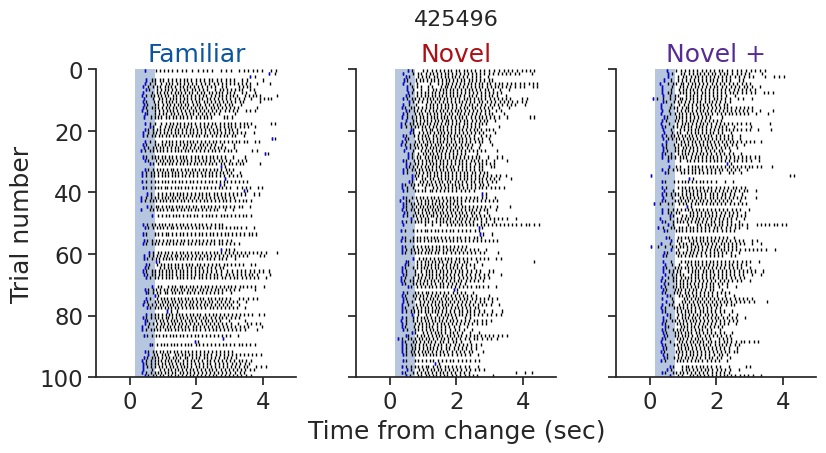

In [11]:
mouse_id = 425496

# Get datasets for each experience level
familiar_experiment_id = platform_experiments[(platform_experiments.mouse_id == mouse_id) &
                                             (platform_experiments.experience_level == 'Familiar')].index.values[0]
familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

novel_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel') &
                                         (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_dataset = loading.get_ophys_dataset(novel_experiment_id)

novel_plus_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel +') &
                                              (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_plus_dataset = loading.get_ophys_dataset(novel_plus_experiment_id)

# Plot lick rasters for F/N/N+
colors = utils.get_experience_level_colors()
figsize = (12, 4)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', save_dir=None, suffix='_familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])
ax[0].set_xlabel('')

trials = novel_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', save_dir=None, suffix='_novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')

trials = novel_plus_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[2] = ppf.plot_lick_raster_for_trials(trials, title='Novel +', save_dir=None, suffix='_novel_plus', ax=ax[2])
ax[2].set_title('Novel +', color=colors[2])
ax[2].set_ylabel('')
ax[2].set_xlabel('')

plt.subplots_adjust(wspace=0.3)
plt.suptitle(mouse_id, x=0.6, y=1.03, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id) + '_F_N_N+_example_fig')

### Behavior performance

/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3937: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3946: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


<Axes: ylabel='d-prime'>

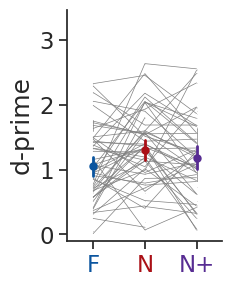

In [12]:
metric = 'mean_dprime_engaged'
stats = behavior_stats_sdk.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='d-prime', ylims=[-0.1, 3.3],
                                      best_image=False, show_mice=True, plot_stats=True,
                                      stripplot=False, show_ns=False,
                                      save_dir=save_dir, folder='behavior_metrics', ax=None)

/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3937: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3946: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


<Axes: ylabel='Hit rate'>

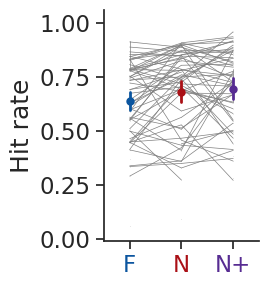

In [13]:
metric = 'mean_hit_rate_engaged'

stats = behavior_stats_sdk.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='Hit rate', stripplot=False,
                                        ylims=[-0.01, 1.01], show_mice=True, plot_stats=True, show_ns=False,
                                        save_dir=save_dir, folder='behavior_metrics', ax=None)

/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3937: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3946: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


<Axes: ylabel='Response latency (s)'>

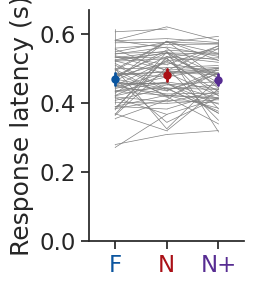

In [14]:
metric = 'response_latency_mean'
stats = behavior_stats_stim.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='Response latency (s)', 
                                    ylims=None, show_mice=True, plot_stats=True, stripplot=False, show_ns=False,
                                      save_dir=save_dir, folder='behavior_metrics', ax=None)

### Event aligned behavior

#### Load dataframes for running, pupil, and licks, for both changes & omissions

In [15]:
#### Multi-session dataframes for behavior variables

epoch_duration_mins = None

# Running speed
running_speed_mdf_changes = loading.get_behavior_multi_session_df('running_speed', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
running_speed_mdf_images = loading.get_behavior_multi_session_df('running_speed', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
running_speed_mdf_omissions = loading.get_behavior_multi_session_df('running_speed', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Pupil width
pupil_mdf_changes = loading.get_behavior_multi_session_df('pupil_width', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
pupil_mdf_images = loading.get_behavior_multi_session_df('pupil_width', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
pupil_mdf_omissions = loading.get_behavior_multi_session_df('pupil_width', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Lick rate
lick_rate_mdf_changes = loading.get_behavior_multi_session_df('lick_rate', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
lick_rate_mdf_images = loading.get_behavior_multi_session_df('lick_rate', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
lick_rate_mdf_omissions = loading.get_behavior_multi_session_df('lick_rate', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


1936
loading files from /scratch/visual_behavior_condition_averages
mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /scratch/visual_behavior_condition_averages/mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
there are 1880 experiments in the full multi_session_df


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


...

removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


1936
loading files from /scratch/visual_behavior_condition_averages
mean_response_df_lick_rate_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved file at /scratch/visual_behavior_condition_averages/mean_response_df_lick_rate_all_omitted_platform_experiment_table.pkl
there are 1602 experiments in the full multi_session_df


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


In [16]:
print(len(pupil_mdf_omissions.behavior_session_id.unique()))
print(len(pupil_mdf_omissions.ophys_experiment_id.unique()))
print(len(pupil_mdf_omissions.mouse_id.unique()))


161
161
63


#### Combined figure - running & pupil

table includes 66 mice


/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1912: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 61 mice


/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1912: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 63 mice


/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1912: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 63 mice


/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1912: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Text(0, 0.5, '')

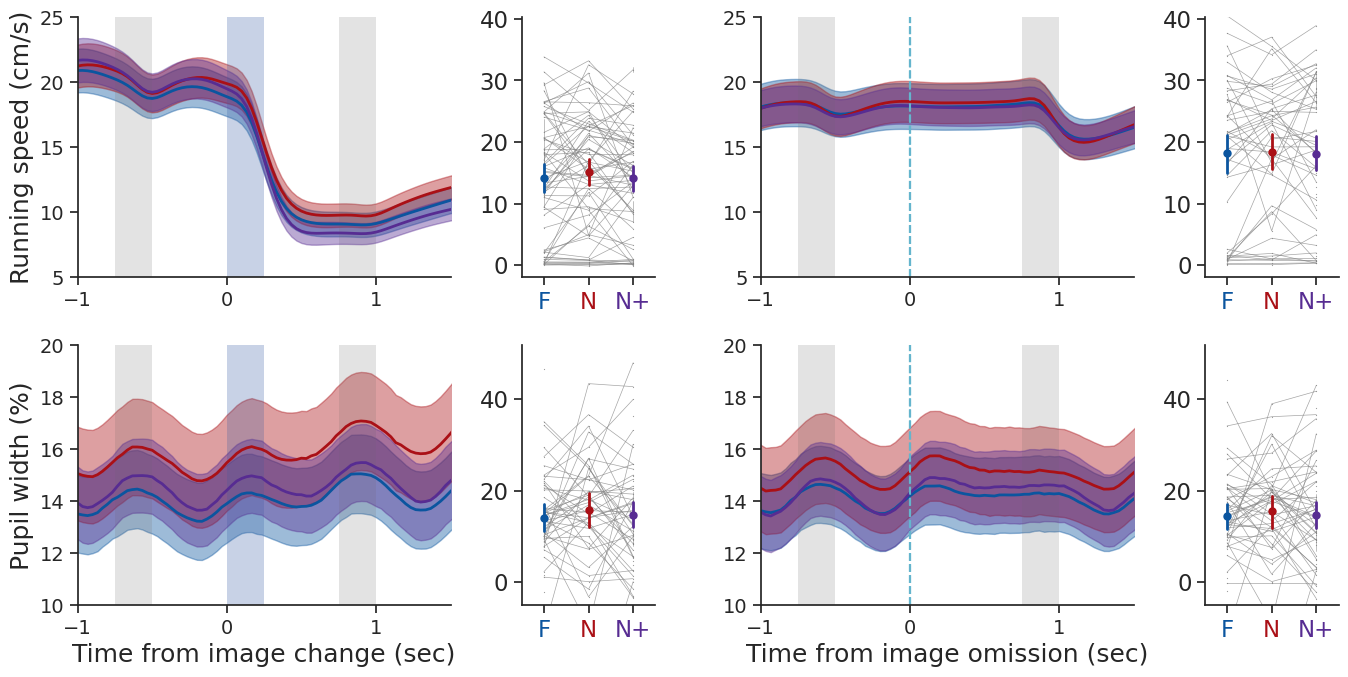

In [17]:
axes_column = 'expts'
hue_column = 'experience_level'
xlim_seconds = [-1, 1.5]
interval_sec = 1

figsize = [2 * 11, 2 * 8.5]
fig = plt.figure(figsize=figsize)


#### Running 

#### Changes

df = running_speed_mdf_changes.copy()
df['expts'] = 'all'

ylims = (-2, 35)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0, 0.22], yspan=[0, 0.2], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'running_speed', 'changes', hue_column, 
                                                ylabel='Running speed (cm/s)', linewidth=2, ylims=(5, 25),
                                                xlim_seconds=xlim_seconds, interval_sec=interval_sec,
                                                xlabel='Time from image change (sec)', ax=ax)
ax.set_xlabel('')

ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.26, 0.34], yspan=[0, 0.2], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'running_speed', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='',ax=ax)
ax.set_ylabel('')



#### Omissions 

df = running_speed_mdf_omissions.copy()
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0, 0.2], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'running_speed', 'omissions', hue_column, ylims=(5, 25),
                                                ylabel='Running speed (cm/s)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('')

ylims = (-2, 35)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0, 0.2], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'running_speed', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Pupil 

#### Changes


df = pupil_mdf_changes.copy()
# Set baseline to 0 instead of 1
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.0, 0.22], yspan=[0.25, 0.45], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'pupil_width', 'changes', hue_column, ylims=(10, 20),
                                                ylabel='Pupil width (%)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image change (sec)', ax=ax)

ylims = (-0.1, 0.5)
ylims = (-5, 45)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.26, 0.34], yspan=[0.25, 0.45], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'pupil_width', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Omissions

df = pupil_mdf_omissions.copy()
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0.25, 0.45], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'pupil_width', 'omissions', hue_column, ylims=(10, 20),
                                                ylabel='Pupil width (%)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_ylabel('')

ylims = (-0.1, 0.5)
ylims = (-5, 45)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0.25, 0.45], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'pupil_width', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')




#### Combined plot including lick rate

table includes 66 mice


/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1912: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 61 mice


/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1912: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 63 mice


...

table includes 66 mice


/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1912: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 66 mice


/root/capsule/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1912: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Text(0, 0.5, '')

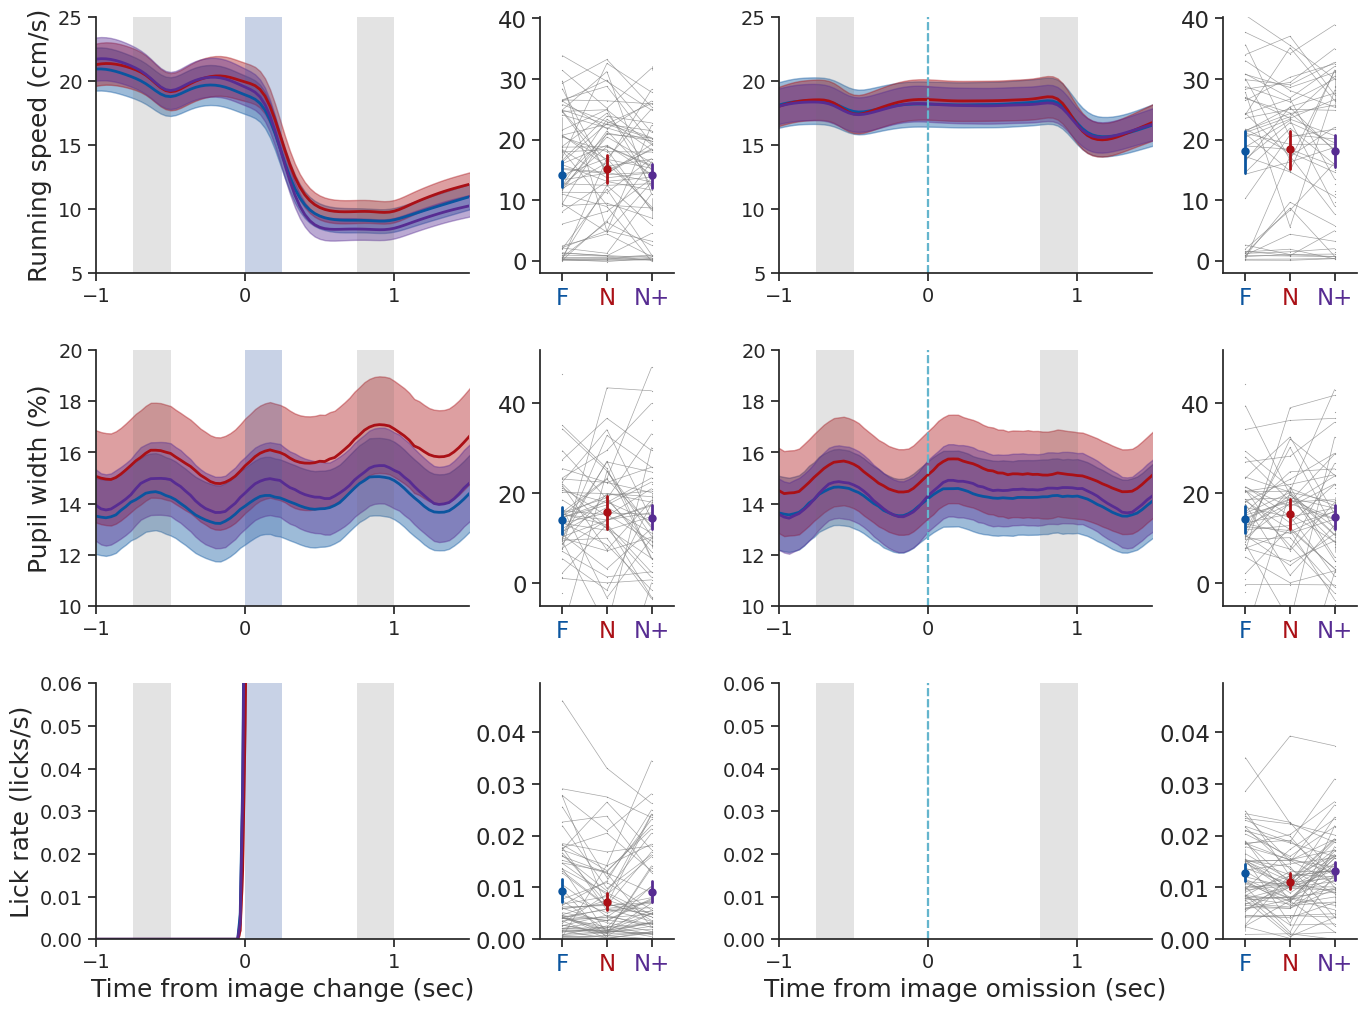

In [18]:
axes_column = 'expts'
hue_column = 'experience_level'
xlim_seconds = [-1, 1.5]
interval_sec = 1

figsize = [2 * 11, 2 * 12]
fig = plt.figure(figsize=figsize)


#### Running 

#### Changes

df = running_speed_mdf_changes.copy()
df['expts'] = 'all'

ylims = (-2, 35)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0, 0.22], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'running_speed', 'changes', hue_column, 
                                                ylabel='Running speed (cm/s)', linewidth=2, ylims=(5, 25),
                                                xlim_seconds=xlim_seconds, interval_sec=interval_sec,
                                                xlabel='Time from image change (sec)', ax=ax)
ax.set_xlabel('')

ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.26, 0.34], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'running_speed', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='',ax=ax)
ax.set_ylabel('')



#### Omissions 

df = running_speed_mdf_omissions.copy()
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'running_speed', 'omissions', hue_column, ylims=(5, 25),
                                                ylabel='Running speed (cm/s)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('')

ylims = (-2, 35)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'running_speed', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Pupil 

#### Changes


df = pupil_mdf_changes.copy()
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.0, 0.22], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'pupil_width', 'changes', hue_column, ylims=(10, 20),
                                                ylabel='Pupil width (%)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image change (sec)', ax=ax)
ax.set_xlabel('')

ylims = (-5, 45)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.26, 0.34], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'pupil_width', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Omissions

df = pupil_mdf_omissions.copy()
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'pupil_width', 'omissions', hue_column, ylims=(10, 20),
                                                ylabel='Pupil width (%)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_ylabel('')
ax.set_xlabel('')

ylims = (-5, 45)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'pupil_width', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Lick rate

#### Changes

df = lick_rate_mdf_changes.copy()
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.0, 0.22], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'lick_rate', 'changes', hue_column, 
                                                ylabel='Lick rate (licks/s)', linewidth=2, ylims=(0, 0.06),
                                                xlim_seconds=xlim_seconds, interval_sec=interval_sec,
                                                xlabel='Time from image change (sec)', ax=ax)

ylims_lick = None
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.26, 0.34], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'lick_rate', 
                                            ylabel='', ylims=(0, 0.043), show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Omissions

df = lick_rate_mdf_omissions.copy()
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'lick_rate', 'omissions', hue_column, ylims=(0, 0.06),
                                                ylabel='Lick rate (licks/s)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_ylabel('')

ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'lick_rate', 
                                            ylabel='', ylims=(0, 0.043), show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')

### Within session changes in behavior

In [19]:
#### Multi-session dataframes for behavior variables

epoch_duration_mins = 5

# Running speed
running_speed_mdf_changes_epochs = loading.get_behavior_multi_session_df('running_speed', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
running_speed_mdf_images_epochs = loading.get_behavior_multi_session_df('running_speed', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
running_speed_mdf_omissions_epochs = loading.get_behavior_multi_session_df('running_speed', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Pupil width
pupil_mdf_changes_epochs = loading.get_behavior_multi_session_df('pupil_width', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
pupil_mdf_images_epochs = loading.get_behavior_multi_session_df('pupil_width', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
pupil_mdf_omissions_epochs = loading.get_behavior_multi_session_df('pupil_width', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Lick rate
lick_rate_mdf_changes_epochs = loading.get_behavior_multi_session_df('lick_rate', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
lick_rate_mdf_images_epochs = loading.get_behavior_multi_session_df('lick_rate', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
lick_rate_mdf_omissions_epochs = loading.get_behavior_multi_session_df('lick_rate', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


1936
loading files from /scratch/visual_behavior_condition_averages
mean_response_df_running_speed_all_is_change_epoch_epoch_dur_5_platform_experiment_table.pkl
loading multi_session_df from saved file at /scratch/visual_behavior_condition_averages/mean_response_df_running_speed_all_is_change_epoch_epoch_dur_5_platform_experiment_table.pkl
there are 1880 experiments in the full multi_session_df


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


...

removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


1936
loading files from /scratch/visual_behavior_condition_averages
mean_response_df_lick_rate_all_omitted_epoch_epoch_dur_5_platform_experiment_table.pkl
loading multi_session_df from saved file at /scratch/visual_behavior_condition_averages/mean_response_df_lick_rate_all_omitted_epoch_epoch_dur_5_platform_experiment_table.pkl
there are 1602 experiments in the full multi_session_df


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


#### Across 5 minute epochs 

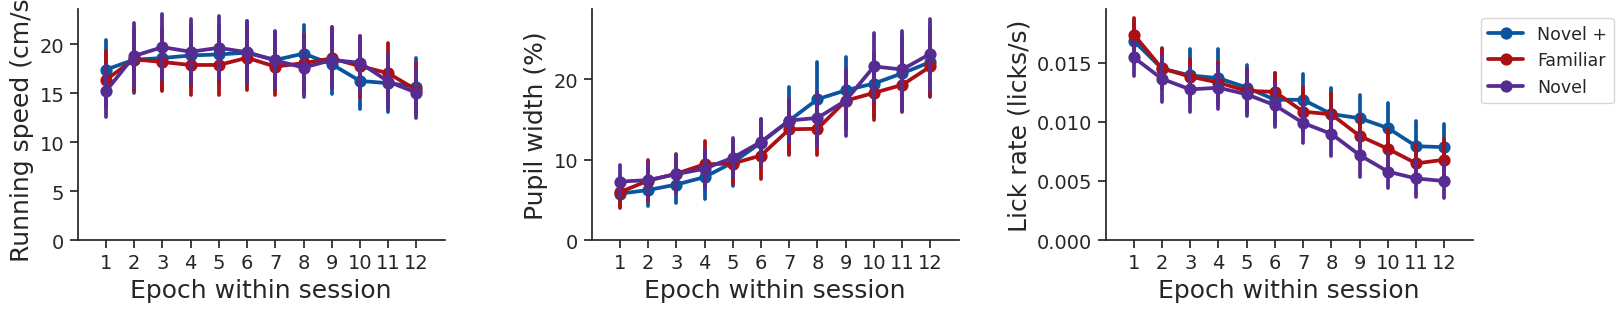

In [20]:
figsize = (18, 3)
fig, ax = plt.subplots(1, 3, figsize=figsize)

i = 0
ax[i] = ppf.plot_mean_response_by_epoch_all_cell_types(running_speed_mdf_images_epochs, metric='mean_response', horizontal=True, ymin=0, 
                                ylabel='Running speed (cm/s)', title='', legend=False, estimator=np.mean, max_epoch=11, ax=ax[i])

i = 1
ax[i] = ppf.plot_mean_response_by_epoch_all_cell_types(pupil_mdf_images_epochs, metric='mean_response', horizontal=True, ymin=0, 
                                ylabel='Pupil width (%)', title='', legend=False, estimator=np.mean, max_epoch=11, ax=ax[i])

i = 2
ax[i] = ppf.plot_mean_response_by_epoch_all_cell_types(lick_rate_mdf_images_epochs, metric='mean_response', horizontal=True, ymin=0, 
                                ylabel='Lick rate (licks/s)', title='', legend=True, estimator=np.mean, max_epoch=11, ax=ax[i])


#### Per cre line

array([<Axes: title={'center': 'Excitatory'}, xlabel='Epoch within session', ylabel='Lick rate (licks/s)'>,
       <Axes: title={'center': 'Sst Inhibitory'}, xlabel='Epoch within session'>,
       <Axes: title={'center': 'Vip Inhibitory'}, xlabel='Epoch within session'>],
      dtype=object)

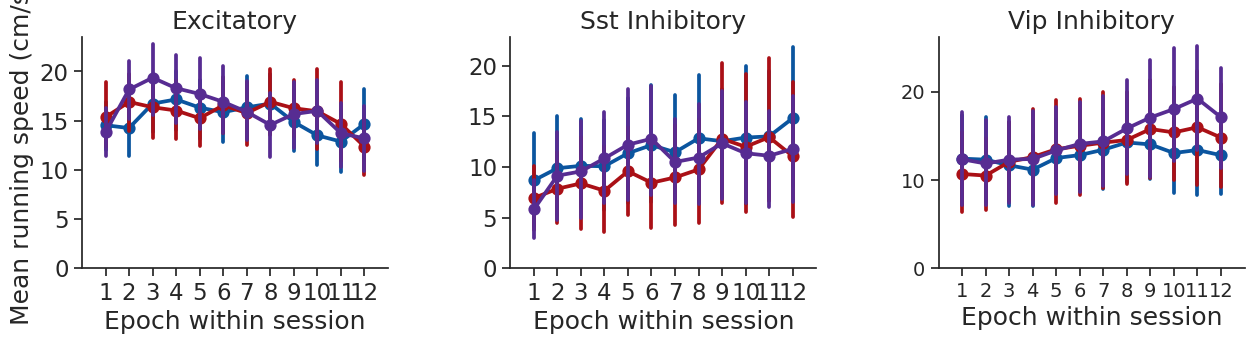

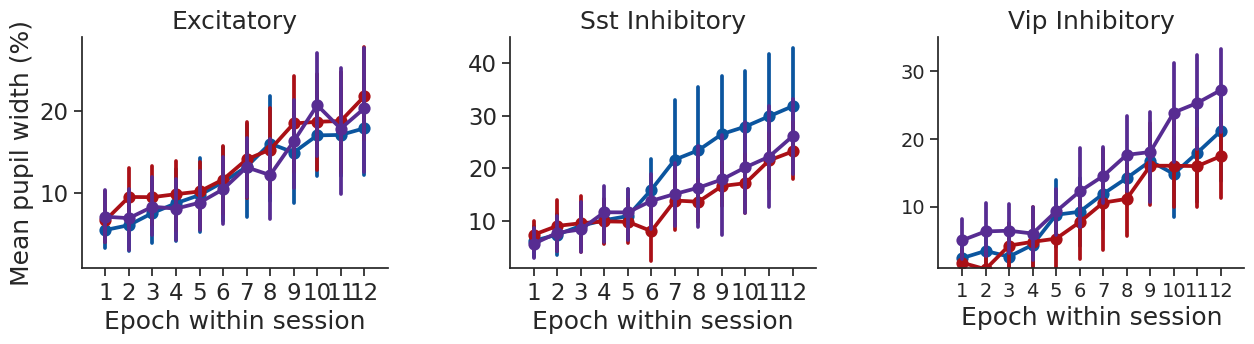

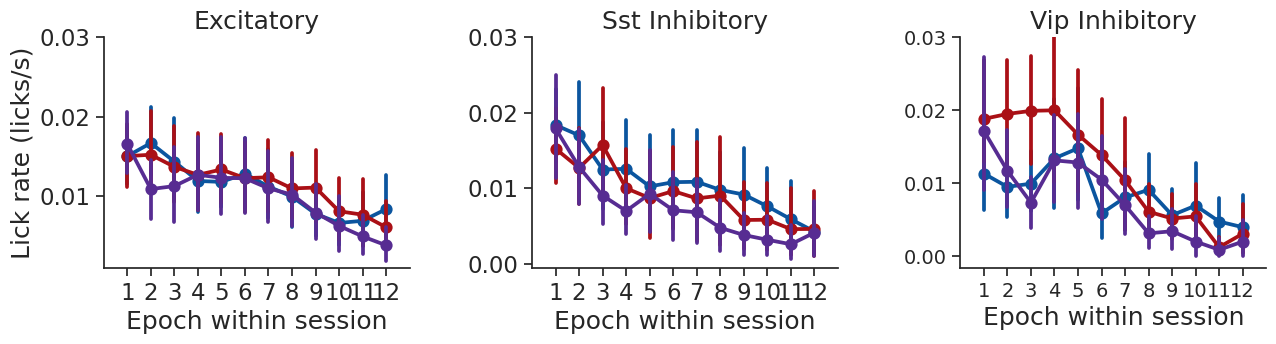

In [21]:
suffix = '_running_speed_images_within_session'
ppf.plot_mean_response_by_epoch(running_speed_mdf_changes_epochs, metric='mean_response', horizontal=True, ymin=0,
                               ylabel='Mean running speed (cm/s)', estimator=np.mean,
                               save_dir=save_dir, folder='within_session_behavior', max_epoch=11, ax=None)

# Pupil width by epoch
suffix = '_pupil_width_images_within_session'
ppf.plot_mean_response_by_epoch(pupil_mdf_changes_epochs, metric='mean_response', horizontal=True, ymin=0.9,
                               ylabel='Mean pupil width (%)', estimator=np.mean,
                               save_dir=save_dir, folder='within_session_behavior', max_epoch=11, ax=None)

# Lick rate by epoch
suffix = '_lick_rate_images_within_session'
ppf.plot_mean_response_by_epoch(lick_rate_mdf_changes_epochs, metric='mean_response', horizontal=True, ymin=None,
                               ylabel='Lick rate (licks/s)', estimator=np.mean, ymax=0.03,
                               save_dir=save_dir, folder='within_session_behavior', max_epoch=11, ax=None)

### Across 10 second bins 

In [22]:
# mouse_id = platform_experiments.mouse_id.unique()[0]
file_dir = os.path.join(loading.get_platform_analysis_cache_dir(), 'visual_behavior_stimulus_behavior_response')
stim_behavior_response_df = pd.DataFrame()
problem_mice = []
for mouse_id in platform_experiments.mouse_id.unique(): 
    filename = str(mouse_id)+'_stimulus_behavior_response_df.csv'
    filepath = os.path.join(file_dir, filename)
    try: 
        df = pd.read_csv(filepath, index_col=0)
        df['mouse_id'] = mouse_id
        stim_behavior_response_df = pd.concat((stim_behavior_response_df, df))
    except:
        problem_mice.append(mouse_id)
print(len(stim_behavior_response_df.mouse_id.unique()))
print(problem_mice)

62
[438912, 435431, 544965, 541329]


In [23]:
stim_behavior = stim_behavior_response_df.merge(platform_experiments.reset_index(), 
                                                            on=['ophys_experiment_id', 'ophys_session_id', 'mouse_id', 'experience_level'], how='left')

# Convert to percentage of baseline                                                       
stim_behavior['mean_Across time in time pupil_width'] = stim_behavior['mean_pupil_width'] - 1
stim_behavior['mean_pupil_width'] = stim_behavior['mean_pupil_width'] * 100
# Start epoch at 1 not zero
# stim_behavior['epoch'] = stim_behavior['epoch'] + 1 # change epoch numbering to start at 1 instead of 0 for easier interpretation in plots

stim_behavior.head()

,stimulus_presentations_id,start_time,relative_time,epoch,is_change,omitted,post_omitted,image_name,mean_running_speed,mean_pupil_width,...,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure,mean_Across time in time pupil_width
0,1,307.176084,0.00000,0,False,False,False,im065,12.685861,106.695455,...,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3,0.066955
1,2,307.926674,0.75059,0,False,False,False,im065,12.339447,106.398520,...,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3,0.063985
2,3,308.677274,1.50119,0,False,False,False,im065,26.097918,105.167729,...,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3,0.051677
3,4,309.427924,2.25184,0,False,False,False,im065,30.444546,102.722607,...,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3,0.027226
4,5,310.178494,3.00241,0,False,False,False,im065,28.378029,102.916830,...,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3,0.029168


In [24]:
image_sdf = stim_behavior[stim_behavior.is_change==False].reset_index()
# Calculate the relative stimulus_presentations_id
image_sdf['stimulus_number'] = image_sdf.groupby(['mouse_id', 'ophys_session_id']).cumcount() + 1

# Check that everything is there
print(len(image_sdf.mouse_id.unique()))


62


In [25]:
metric = 'mean_pupil_width'
x = 'stimulus_number'
df = image_sdf[image_sdf.epoch<10]
df = df[df.stimulus_number<31]
title = 'Pupil width across stimulus presentations'
ylabel = 'Pupil width (%)'

plot_metric_over_repeats(df, metric, x, title, ylabel=ylabel, save_dir=None, folder='within_session_behavior')
plot_metric_over_repeats_for_cell_types(df, metric, x, ylabel=ylabel,   save_dir=None, folder='within_session_behavior')


NameError: name 'plot_metric_over_repeats' is not defined

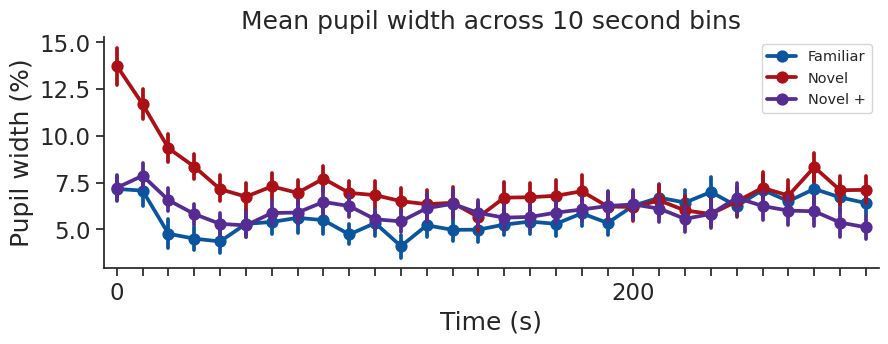

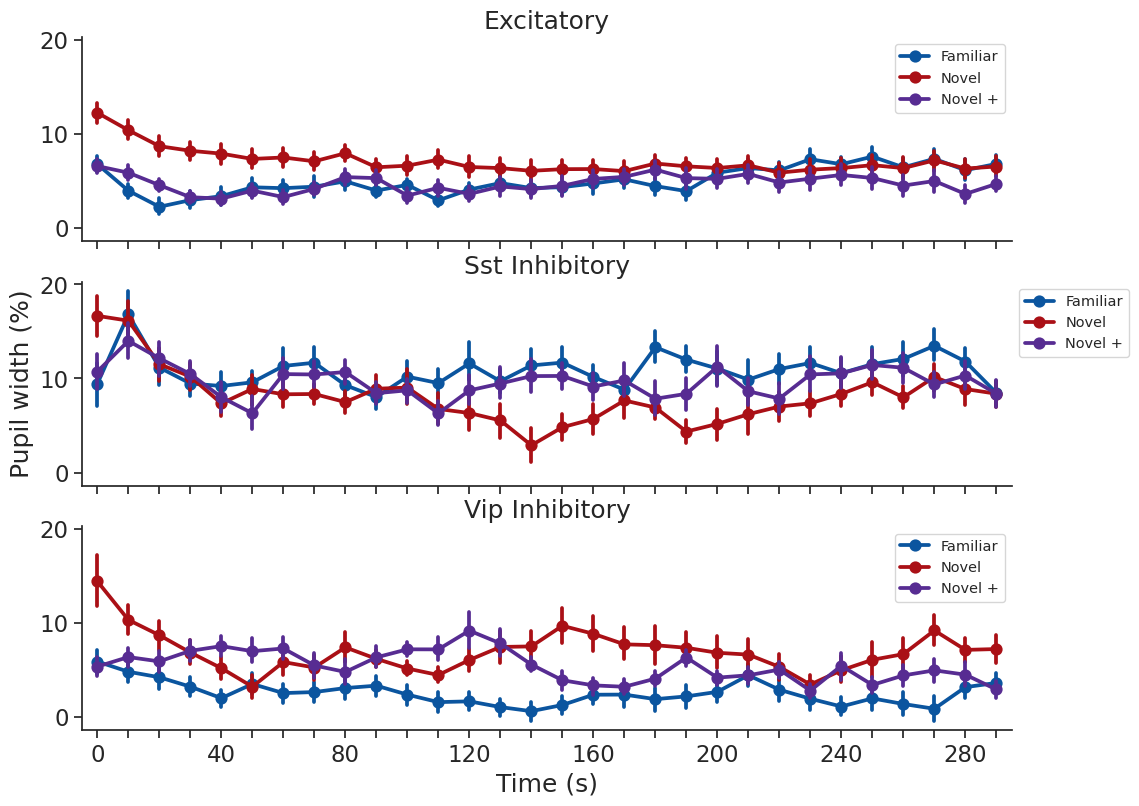

In [ ]:
# Grop into 10 second bins
df = image_sdf.copy()
df = df[df.epoch<5]

bin_size = 10
df['seconds'] = pd.cut(df['relative_time'], 
                        bins=range(0, int(df['relative_time'].max()) + bin_size, bin_size), 
                        right=False,  # Include the left edge, exclude the right edge
                        # labels=False) # Use bin numbers as labels
                        labels=[i for i in range(0, int(df['relative_time'].max()), bin_size)])

x = 'seconds'
metric = 'mean_pupil_width'
title = metric.replace('_', ' ').capitalize()+' across 10 second bins'

plot_metric_over_repeats(df, metric, x, title, xlabel='Time (s)', ylabel='Pupil width (%)', 
                            save_dir=save_dir, folder='within_session_behavior')

plot_metric_over_repeats_for_cell_types(df, metric, x, xlabel='Time (s)', ylabel='Pupil width (% of baseline)', 
                            save_dir=save_dir, folder='within_session_behavior')


<Axes: title={'center': 'Pupil width over 1 min bins'}, xlabel='Epoch', ylabel='Mean pupil width'>

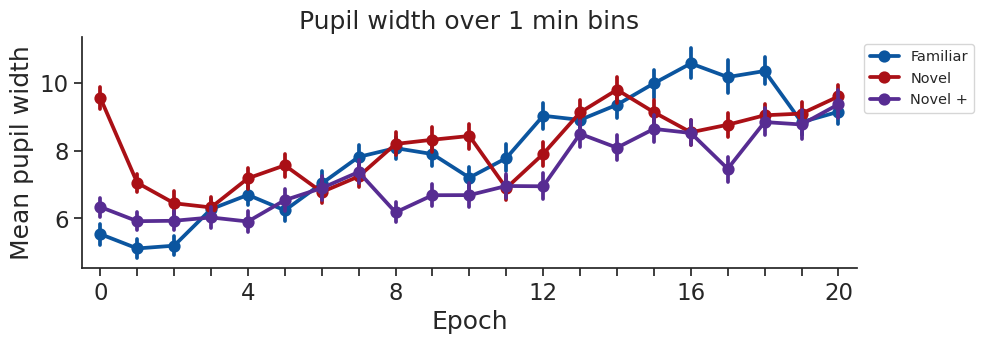

In [ ]:
metric = 'mean_pupil_width'
x = 'epoch'
df = image_sdf[image_sdf.epoch<21]
title = 'Pupil width over 1 min bins'

plot_metric_over_repeats(df, metric, x, title, save_dir=None, folder='metrics_over_time_in_session')
# plot_metric_over_repeats_for_cell_types(df, metric, x, save_dir=None, folder='metrics_over_time_in_session')


In [ ]:

% matplotlin

## Schematics

### Load stimulus images for schematics (Panels A, B)

Load stimulus templates from the familiar dataset to use in the image change and omission schematics.

In [ ]:
# Load stimulus templates from familiar dataset
stimulus_templates = familiar_dataset.stimulus_templates.copy()
image_pre = stimulus_templates.loc['im061']['unwarped'].copy()   # repeated image
image_post = stimulus_templates.loc['im065']['unwarped'].copy()  # change image
print(f"Loaded stimulus images: im061 shape={image_pre.shape}, im065 shape={image_post.shape}")

Loaded stimulus images: im061 shape=(1200, 1920), im065 shape=(1200, 1920)


#### Panel A schematic: Image change trial structure

Shows a sequence of repeated images (250 ms each) interleaved with gray screens (500 ms), followed by an image identity change and reward window (750 ms).

<Axes: >

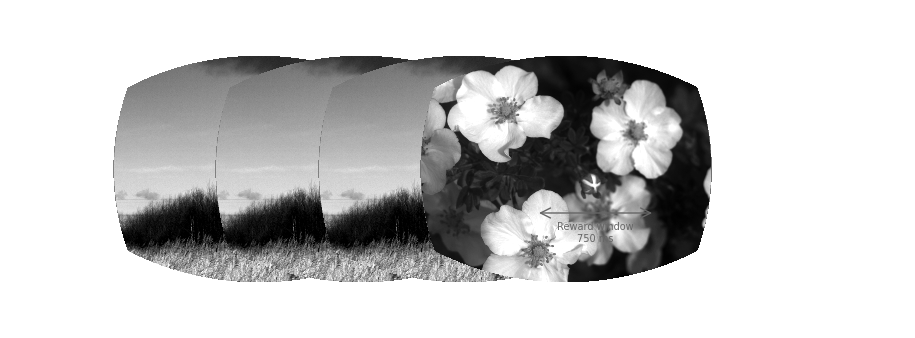

In [ ]:
def plot_figure_2A_schematic(image_pre=None, image_post=None, ax=None,
                              save_dir=None, folder=None, suffix=''):
    """
    Reproduce the Figure 2A image change schematic showing a sequence of
    repeated images (250 ms each) interleaved with gray screens (500 ms),
    followed by an image identity change and reward window.

    Parameters
    ----------
    image_pre : 2D array, optional
        The repeated image shown before the change (e.g., im061 unwarped).
    image_post : 2D array, optional
        The new image shown after the change (e.g., im065 unwarped).
    ax : matplotlib Axes, optional
        If provided, plot on this axes. Otherwise create a new figure.
    save_dir : str, optional
        Directory to save figure.
    folder : str, optional
        Subfolder within save_dir.
    suffix : str
        Suffix for saved filename.

    Returns
    -------
    ax : matplotlib Axes
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 2.8))
    else:
        fig = ax.figure

    ax.set_xlim(-1.5, 22)
    ax.set_ylim(-3.8, 4.5)
    ax.axis('off')

    # Layout parameters
    img_width = 1.8
    gray_width = 1.0
    img_height = 2.0
    y_center = 0
    y_bot = y_center - img_height / 2
    zoom = 0.18

    # Title
    ax.text(10, 3.8, 'Image change', fontsize=11, fontweight='bold',
            ha='center', va='center', color='#333333')

    # Ellipsis dots on far left
    for dx in [0, 0.5, 1.0]:
        ax.plot(-0.5 + dx, y_center, 'o', color='#999999', markersize=3, zorder=2)

    # Sequence: [img_pre] [gray] [img_pre] [gray] [img_pre] [gray] [img_post]
    x_cursor = 1.5
    n_repeats = 3

    positions_pre = []
    positions_gray = []

    for i in range(n_repeats):
        # Image frame
        positions_pre.append(x_cursor)
        rect = mpatches.FancyBboxPatch((x_cursor, y_bot), img_width, img_height,
                                        boxstyle='round,pad=0.02',
                                        facecolor='white', edgecolor='#cccccc',
                                        linewidth=0.5, zorder=1)
        ax.add_patch(rect)
        if image_pre is not None:
            im = OffsetImage(image_pre, zoom=zoom, cmap='gray')
            ab = AnnotationBbox(im, (x_cursor + img_width / 2, y_center),
                               frameon=False, zorder=3)
            ax.add_artist(ab)
        x_cursor += img_width + 0.15

        # Gray screen
        positions_gray.append(x_cursor)
        rect_gray = mpatches.FancyBboxPatch((x_cursor, y_bot), gray_width, img_height,
                                             boxstyle='round,pad=0.02',
                                             facecolor='#d0d0d0', edgecolor='#bbbbbb',
                                             linewidth=0.5, zorder=1)
        ax.add_patch(rect_gray)
        x_cursor += gray_width + 0.15

    # Change image (different identity) with red border
    change_x = x_cursor
    rect_change = mpatches.FancyBboxPatch((change_x, y_bot), img_width, img_height,
                                           boxstyle='round,pad=0.02',
                                           facecolor='white', edgecolor='#cc3333',
                                           linewidth=1.5, zorder=1)
    ax.add_patch(rect_change)
    if image_post is not None:
        im_post = OffsetImage(image_post, zoom=zoom, cmap='gray')
        ab_post = AnnotationBbox(im_post, (change_x + img_width / 2, y_center),
                                 frameon=False, zorder=3)
        ax.add_artist(ab_post)

    # Reward window bracket below change image
    bracket_y = y_bot - 0.7
    bracket_left = change_x
    bracket_right = change_x + img_width + 1.8
    ax.annotate('', xy=(bracket_left, bracket_y), xytext=(bracket_right, bracket_y),
                arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.0))
    ax.text((bracket_left + bracket_right) / 2, bracket_y - 0.35,
            'Reward window\n750 ms', fontsize=7, ha='center', va='top',
            color='#666666')

    # Ellipsis dots after change
    for dx in [0, 0.5, 1.0]:
        ax.plot(change_x + img_width + 0.5 + dx, y_center, 'o',
                color='#999999', markersize=3, zorder=2)

    if save_dir is not None:
        figsize = fig.get_size_inches()
        utils.save_figure(fig, figsize, save_dir, folder,
                          'figure_2A_schematic' + suffix, formats=['.pdf', '.png'])

    return ax


# Generate Panel A schematic
plot_figure_2A_schematic(image_pre=image_pre, image_post=image_post,
                          save_dir=save_dir, folder='schematics', suffix='')

#### Panel B schematic: Image omission trial structure

Shows a sequence of repeated images interleaved with gray screens, then an unexpected omission (gray where an image was expected). Omissions were 5% of non-change image presentations and violated learned expectations of stimulus timing.

<Axes: >

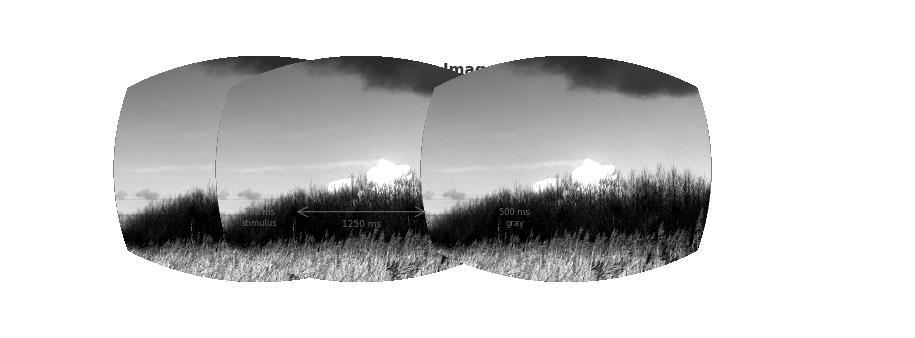

In [ ]:
def plot_figure_2B_schematic(image=None, ax=None,
                              save_dir=None, folder=None, suffix=''):
    """
    Reproduce the Figure 2B image omission schematic showing a sequence of
    repeated images interleaved with gray screens, then an unexpected omission
    (gray where an image was expected).

    Parameters
    ----------
    image : 2D array, optional
        The repeated image (e.g., im061 unwarped).
    ax : matplotlib Axes, optional
        If provided, plot on this axes. Otherwise create a new figure.
    save_dir : str, optional
        Directory to save figure.
    folder : str, optional
        Subfolder within save_dir.
    suffix : str
        Suffix for saved filename.

    Returns
    -------
    ax : matplotlib Axes
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 2.8))
    else:
        fig = ax.figure

    ax.set_xlim(-1.5, 22)
    ax.set_ylim(-3.8, 4.5)
    ax.axis('off')

    # Layout parameters
    img_width = 1.8
    gray_width = 1.0
    img_height = 2.0
    y_center = 0
    y_bot = y_center - img_height / 2
    zoom = 0.18

    # Title
    ax.text(10, 3.8, 'Image omission', fontsize=11, fontweight='bold',
            ha='center', va='center', color='#333333')

    # Ellipsis dots on far left
    for dx in [0, 0.5, 1.0]:
        ax.plot(-0.5 + dx, y_center, 'o', color='#999999', markersize=3, zorder=2)

    x_cursor = 1.5

    # --- Image 1 ---
    img1_x = x_cursor
    rect1 = mpatches.FancyBboxPatch((x_cursor, y_bot), img_width, img_height,
                                     boxstyle='round,pad=0.02',
                                     facecolor='white', edgecolor='#cccccc',
                                     linewidth=0.5, zorder=1)
    ax.add_patch(rect1)
    if image is not None:
        im1 = OffsetImage(image, zoom=zoom, cmap='gray')
        ab1 = AnnotationBbox(im1, (x_cursor + img_width / 2, y_center),
                             frameon=False, zorder=3)
        ax.add_artist(ab1)
    x_cursor += img_width + 0.15

    # --- Gray 1 ---
    gray1_x = x_cursor
    rect_g1 = mpatches.FancyBboxPatch((x_cursor, y_bot), gray_width, img_height,
                                       boxstyle='round,pad=0.02',
                                       facecolor='#d0d0d0', edgecolor='#bbbbbb',
                                       linewidth=0.5, zorder=1)
    ax.add_patch(rect_g1)
    x_cursor += gray_width + 0.15

    # --- Image 2 ---
    img2_x = x_cursor
    rect2 = mpatches.FancyBboxPatch((x_cursor, y_bot), img_width, img_height,
                                     boxstyle='round,pad=0.02',
                                     facecolor='white', edgecolor='#cccccc',
                                     linewidth=0.5, zorder=1)
    ax.add_patch(rect2)
    if image is not None:
        im2 = OffsetImage(image, zoom=zoom, cmap='gray')
        ab2 = AnnotationBbox(im2, (x_cursor + img_width / 2, y_center),
                             frameon=False, zorder=3)
        ax.add_artist(ab2)
    x_cursor += img_width + 0.15

    # --- Gray 2 ---
    gray2_x = x_cursor
    rect_g2 = mpatches.FancyBboxPatch((x_cursor, y_bot), gray_width, img_height,
                                       boxstyle='round,pad=0.02',
                                       facecolor='#d0d0d0', edgecolor='#bbbbbb',
                                       linewidth=0.5, zorder=1)
    ax.add_patch(rect_g2)
    x_cursor += gray_width + 0.15

    # --- OMISSION (dashed cyan border, light gray fill) ---
    omission_x = x_cursor
    rect_omit = mpatches.FancyBboxPatch((x_cursor, y_bot), img_width, img_height,
                                         boxstyle='round,pad=0.02',
                                         facecolor='#e8e8e8', edgecolor='#44aacc',
                                         linewidth=1.5, linestyle='--', zorder=1)
    ax.add_patch(rect_omit)
    # Dashed cyan vertical line indicating expected stimulus timing
    ax.plot([x_cursor + img_width / 2, x_cursor + img_width / 2],
            [y_bot - 0.15, y_bot + img_height + 0.15],
            ls='--', color='#44aacc', lw=1.5, zorder=2, alpha=0.7)
    x_cursor += img_width + 0.15

    # --- Gray 3 (after omission) ---
    gray3_x = x_cursor
    rect_g3 = mpatches.FancyBboxPatch((x_cursor, y_bot), gray_width, img_height,
                                       boxstyle='round,pad=0.02',
                                       facecolor='#d0d0d0', edgecolor='#bbbbbb',
                                       linewidth=0.5, zorder=1)
    ax.add_patch(rect_g3)
    x_cursor += gray_width + 0.15

    # --- Image 3 (resumes after omission) ---
    img3_x = x_cursor
    rect3 = mpatches.FancyBboxPatch((x_cursor, y_bot), img_width, img_height,
                                     boxstyle='round,pad=0.02',
                                     facecolor='white', edgecolor='#cccccc',
                                     linewidth=0.5, zorder=1)
    ax.add_patch(rect3)
    if image is not None:
        im3 = OffsetImage(image, zoom=zoom, cmap='gray')
        ab3 = AnnotationBbox(im3, (x_cursor + img_width / 2, y_center),
                             frameon=False, zorder=3)
        ax.add_artist(ab3)
    x_cursor += img_width

    # Ellipsis dots after
    for dx in [0, 0.5, 1.0]:
        ax.plot(x_cursor + 0.5 + dx, y_center, 'o',
                color='#999999', markersize=3, zorder=2)

    # --- Timing annotations ---
    anno_y = y_bot - 0.5

    # "250 ms stimulus" under first image
    ax.text(img1_x + img_width / 2, anno_y, '250 ms\nstimulus', fontsize=6,
            ha='center', va='top', color='#666666')

    # Bracket spanning gray1 + image2 + gray2 = 1250 ms total cycle
    bracket_y2 = anno_y - 0.15
    bracket_left = gray1_x
    bracket_right = gray2_x + gray_width
    ax.annotate('', xy=(bracket_left, bracket_y2), xytext=(bracket_right, bracket_y2),
                arrowprops=dict(arrowstyle='<->', color='#666666', lw=0.8))
    ax.text((bracket_left + bracket_right) / 2, bracket_y2 - 0.3,
            '1250 ms', fontsize=6.5, ha='center', va='top', color='#666666')

    # "500 ms gray" under gray3
    ax.text(gray3_x + gray_width / 2, anno_y, '500 ms\ngray', fontsize=6,
            ha='center', va='top', color='#666666')

    if save_dir is not None:
        figsize = fig.get_size_inches()
        utils.save_figure(fig, figsize, save_dir, folder,
                          'figure_2B_schematic' + suffix, formats=['.pdf', '.png'])

    return ax


# Generate Panel B schematic
plot_figure_2B_schematic(image=image_pre,
                          save_dir=save_dir, folder='schematics', suffix='')

#### Panel D schematic: Training timeline / experimental design

Shows behavior training sessions transitioning to 2-photon imaging with Familiar, Novel, and Novel+ sessions.

<Axes: >

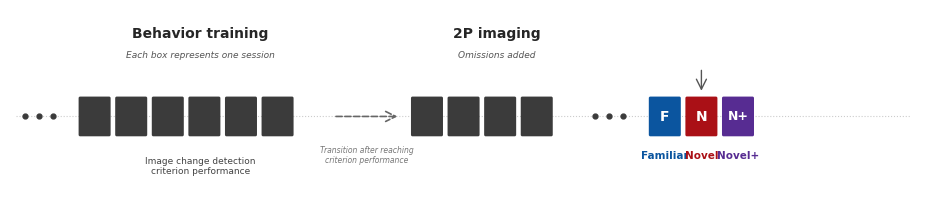

In [ ]:
def plot_figure_2D_schematic(ax=None, save_dir=None, folder=None, suffix=''):
    """
    Reproduce the Figure 2D training timeline schematic showing
    the experimental design: behavior training sessions followed by
    2-photon imaging sessions (Familiar, Novel, Novel+).
    """
    # --- Colors ---
    reds = sns.color_palette('Reds_r', 6)[:5][::2]
    blues = sns.color_palette('Blues_r', 6)[:5][::2]
    purples = sns.color_palette('Purples_r', 6)[:5][::2]
    familiar_color = blues[0]
    novel_color = reds[0]
    novel_plus_color = purples[0]
    training_color = '#3b3b3b'
    text_gray = '#555555'

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(12, 2.5))
    else:
        fig = ax.figure

    ax.set_xlim(-0.5, 30)
    ax.set_ylim(-2.8, 3.5)
    ax.axis('off')

    box_w = 0.95
    box_h = 1.2
    box_y = -box_h / 2
    gap = 0.25

    # Horizontal dotted timeline
    ax.plot([-0.3, 29], [0, 0], ls=':', color='#cccccc', lw=0.8, zorder=0)

    # ---- Behavior training (left side) ----
    for dx in [0, 0.45, 0.9]:
        ax.plot(dx, 0, 'o', color=training_color, markersize=3.5, zorder=2)

    training_start_x = 1.8
    n_training = 6
    for i in range(n_training):
        x = training_start_x + i * (box_w + gap)
        rect = mpatches.FancyBboxPatch((x, box_y), box_w, box_h,
                                        boxstyle='round,pad=0.05',
                                        facecolor=training_color, edgecolor='none', zorder=2)
        ax.add_patch(rect)

    training_end_x = training_start_x + n_training * (box_w + gap) - gap + box_w
    training_center = (training_start_x + training_end_x) / 2
    ax.text(training_center, 2.7, 'Behavior training', fontsize=10, fontweight='bold', ha='center', va='center')
    ax.text(training_center, 2.0, 'Each box represents one session', fontsize=6.5,
            ha='center', va='center', fontstyle='italic', color=text_gray)
    ax.text(training_center, -1.3, 'Image change detection\ncriterion performance', fontsize=6.5,
            ha='center', va='top', color='#444444')

    # ---- Transition arrow ----
    arrow_start_x = training_end_x + 0.4
    arrow_end_x = arrow_start_x + 2.2
    ax.annotate('', xy=(arrow_end_x, 0), xytext=(arrow_start_x, 0),
                arrowprops=dict(arrowstyle='->', color='#666666', lw=1.2, ls='--'), zorder=2)
    ax.text((arrow_start_x + arrow_end_x) / 2, -0.95,
            'Transition after reaching\ncriterion performance', fontsize=5.5,
            ha='center', va='top', color='#777777', fontstyle='italic')

    # ---- 2P imaging — dark boxes ----
    imaging_start_x = arrow_end_x + 0.4
    n_familiar_imaging = 4
    for i in range(n_familiar_imaging):
        x = imaging_start_x + i * (box_w + gap)
        rect = mpatches.FancyBboxPatch((x, box_y), box_w, box_h,
                                        boxstyle='round,pad=0.05',
                                        facecolor=training_color, edgecolor='none', zorder=2)
        ax.add_patch(rect)

    familiar_imaging_end = imaging_start_x + n_familiar_imaging * (box_w + gap) - gap + box_w
    imaging_center = (imaging_start_x + familiar_imaging_end) / 2
    ax.text(imaging_center, 2.7, '2P imaging', fontsize=10, fontweight='bold', ha='center', va='center')
    ax.text(imaging_center, 2.0, 'Omissions added', fontsize=6.5,
            ha='center', va='center', fontstyle='italic', color=text_gray)

    # Ellipsis dots after imaging boxes
    dot_start = familiar_imaging_end + 0.5
    for dx in [0, 0.45, 0.9]:
        ax.plot(dot_start + dx, 0, 'o', color=training_color, markersize=3.5, zorder=2)

    # ---- Selected sessions: F, N, N+ colored boxes ----
    selected_start_x = dot_start + 1.8

    rect_F = mpatches.FancyBboxPatch((selected_start_x, box_y), box_w, box_h,
                                      boxstyle='round,pad=0.05', facecolor=familiar_color, edgecolor='none', zorder=2)
    ax.add_patch(rect_F)
    ax.text(selected_start_x + box_w / 2, 0, 'F', fontsize=10, fontweight='bold', ha='center', va='center', color='white')

    novel_x = selected_start_x + box_w + gap
    rect_N = mpatches.FancyBboxPatch((novel_x, box_y), box_w, box_h,
                                      boxstyle='round,pad=0.05', facecolor=novel_color, edgecolor='none', zorder=2)
    ax.add_patch(rect_N)
    ax.text(novel_x + box_w / 2, 0, 'N', fontsize=10, fontweight='bold', ha='center', va='center', color='white')

    novel_plus_x = novel_x + box_w + gap
    rect_Np = mpatches.FancyBboxPatch((novel_plus_x, box_y), box_w, box_h,
                                       boxstyle='round,pad=0.05', facecolor=novel_plus_color, edgecolor='none', zorder=2)
    ax.add_patch(rect_Np)
    ax.text(novel_plus_x + box_w / 2, 0, 'N+', fontsize=9, fontweight='bold', ha='center', va='center', color='white')

    label_y = -1.1
    ax.text(selected_start_x + box_w / 2, label_y, 'Familiar', fontsize=7.5, fontweight='bold', ha='center', va='top', color=familiar_color)
    ax.text(novel_x + box_w / 2, label_y, 'Novel', fontsize=7.5, fontweight='bold', ha='center', va='top', color=novel_color)
    ax.text(novel_plus_x + box_w / 2, label_y, 'Novel+', fontsize=7.5, fontweight='bold', ha='center', va='top', color=novel_plus_color)

    mid_selected = (selected_start_x + novel_plus_x + box_w) / 2
    ax.annotate('', xy=(mid_selected, box_h / 2 + 0.15), xytext=(mid_selected, 1.6),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.0), zorder=2)

    if save_dir is not None:
        figsize = fig.get_size_inches()
        utils.save_figure(fig, figsize, save_dir, folder,
                          'figure_2D_schematic' + suffix, formats=['.pdf', '.png'])

    return ax


# Generate Panel D schematic
plot_figure_2D_schematic(save_dir=save_dir, folder='schematics', suffix='')